### P-dispersion

The p-dispersion problem consists of locating $p$ facilities in such a way that the minimum distance between any pair of selected facilities is as large as possible. Let $d_{ij}$ denote the distance between node $i$ and node $j$.

Finally, we define the following decision variable:

$$
y_i =
\begin{cases}
1 & \text{if a facility is located at candidate site } i, \\
0 & \text{otherwise.}
\end{cases}
$$

By introducing an auxiliary variable $r$, the problem can be linearized as follows:

$$
\begin{aligned}
\text{max} \quad & r \\
\text{subject to} \quad
& r \leq d_{ij} + M(2 - y_i - y_j) \quad \forall i \in I,\; j \in J: i < j \\
& \sum_{i \in I} y_i = p \\
& y_i \in \{0,1\} \quad \forall i \in I
\end{aligned}
$$

In [1]:
%pip install gurobipy
from gurobipy import Model, GRB, quicksum
import numpy as np

In [2]:
# Number of candidate facility sites
num_facilities = 5

# Number of customers
num_customers = 5

# Sets
I = range(num_facilities)
J = range(num_customers)

# Symmetric service cost matrix
c = np.array([[0, 3, 3, 6, 3],
              [3, 0, 4, 5, 5],
              [3, 4, 0, 2, 4],
              [6, 5, 2, 0, 5],
              [3, 5, 4, 5, 0]])

# Customer demand
d = np.array([10, 8, 5, 8, 12])

# Number of facilities to locate
p = 2

# A big number
M = float(np.max(c)) + 1

In [3]:
# Define model
m = Model("p-dispersion")

# Decision variables
y = m.addVars(I, vtype=GRB.BINARY, name="x")
r = m.addVar(vtype=GRB.CONTINUOUS, name="r")

# Objetive function
m.setObjective(r, GRB.MAXIMIZE)

# Constraints
for i in I:
    for j in I:
        if i < j:
            m.addConstr(r <= M * (2 - y[i] - y[j]) + c[i][j], name=f"distancia_{i}_{j}")

m.addConstr(quicksum(y[i] for i in I) == p, name="cardinalidad")

# Optimize
m.optimize()


Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 11 rows, 6 columns and 35 nonzeros (Max)
Model fingerprint: 0xcbe2d3af
Model has 1 linear objective coefficients
Variable types: 1 continuous, 5 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 7e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e+00, 2e+01]

Found heuristic solution: objective 3.0000000
Presolve time: 0.00s
Presolved: 11 rows, 6 columns, 35 nonzeros
Variable types: 0 continuous, 6 integer (5 binary)

Root relaxation: objective 1.106897e+01, 9 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def solve_and_plot_p_dispersion(n=5, p=3, seed=42, coord_range=(0, 100), metric="euclidean"):

    rng = np.random.default_rng(seed)
    I = range(n)

    points = rng.uniform(coord_range[0], coord_range[1], size=(n, 2))

    d = np.zeros((n, n), dtype=float)
    for i in I:
        for j in I:
            if i == j:
                d[i, j] = 0.0
            elif i < j:
                dx = points[i, 0] - points[j, 0]
                dy = points[i, 1] - points[j, 1]
                if metric.lower() == "euclidean":
                    dist = float(np.sqrt(dx * dx + dy * dy))
                elif metric.lower() == "manhattan":
                    dist = float(abs(dx) + abs(dy))
                else:
                    raise ValueError("metric must be 'euclidean' or 'manhattan'")
                d[i, j] = d[j, i] = dist

    # Big-M
    M = float(np.max(d))

    m = Model("p-dispersion")
    y = m.addVars(I, vtype=GRB.BINARY, name="y")
    r = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, name="r")

    m.setObjective(r, GRB.MAXIMIZE)
    for i in I:
        for j in I:
            if i < j:
                m.addConstr(r <= d[i, j] + M * (2 - y[i] - y[j]))

    m.addConstr(quicksum(y[i] for i in I) == p)
    m.optimize()

    selected_points = [i for i in I if y[i].X > 0.5]
    print(f"Selected points: {selected_points}")
    print(f"Minimum distance among selected points (r): {r.X:.4f}")

    fig, ax = plt.subplots(figsize=(8, 7))

    # All points
    ax.scatter(points[:, 0], points[:, 1], marker="o")
    for i in I:
        ax.annotate(f"P{i}", (points[i, 0], points[i, 1]), xytext=(5, 5), textcoords="offset points")

    # Selected points (highlighted)
    if selected_points:
        ax.scatter(points[selected_points, 0], points[selected_points, 1], marker="s")

        # Lines between selected pairs
        for a_idx in range(len(selected_points)):
            for b_idx in range(a_idx + 1, len(selected_points)):
                i = selected_points[a_idx]
                j = selected_points[b_idx]
                ax.plot([points[i, 0], points[j, 0]], [points[i, 1], points[j, 1]], linewidth=1)

        # Show the pair that defines the minimum distance (if p >= 2)
        if len(selected_points) >= 2:
            best_pair = None
            best_val = float("inf")
            for a_idx in range(len(selected_points)):
                for b_idx in range(a_idx + 1, len(selected_points)):
                    i = selected_points[a_idx]
                    j = selected_points[b_idx]
                    if d[i, j] < best_val:
                        best_val = d[i, j]
                        best_pair = (i, j)
            i, j = best_pair
            midx = (points[i, 0] + points[j, 0]) / 2
            midy = (points[i, 1] + points[j, 1]) / 2
            ax.annotate(f"min={best_val:.2f}", (midx, midy), xytext=(5, 5), textcoords="offset points")

    ax.set_title(f"P-dispersion (p={p}) - r={r.X:.4f} - metric: {metric}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.axis("equal")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return m, d, selected_points, points



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1771 rows, 61 columns and 5370 nonzeros (Max)
Model fingerprint: 0x864047b5
Model has 1 linear objective coefficients
Variable types: 1 continuous, 60 integer (60 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+00, 4e+02]

Found heuristic solution: objective 5.4249867
Presolve time: 0.03s
Presolved: 1771 rows, 61 columns, 5370 nonzeros
Variable types: 1 continuous, 60 integer (60 binary)

Root relaxation: objective 2.262167e+02, 152 iterations, 0.01 seconds (0.01 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

  

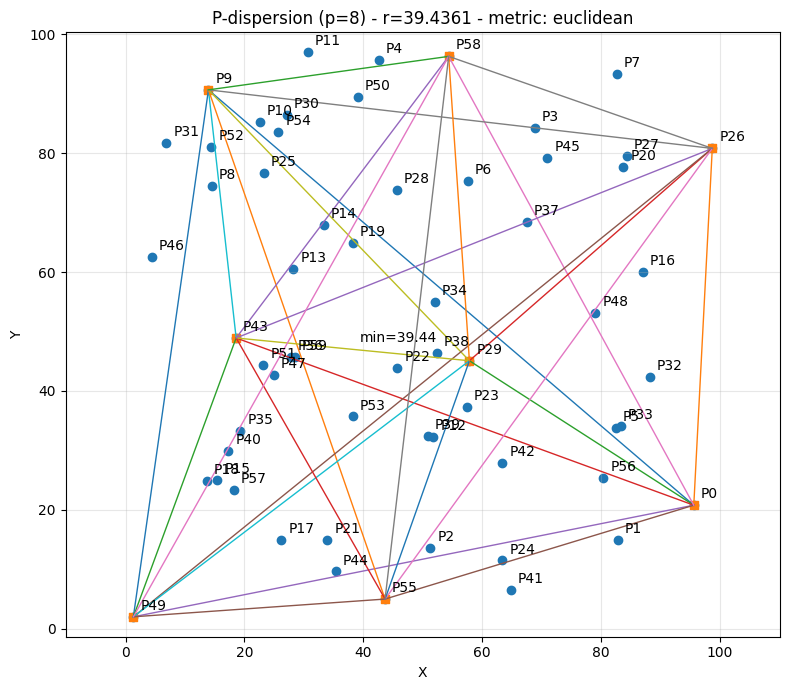

In [5]:
model, distances, selected, pts = solve_and_plot_p_dispersion(n=60, p=8, seed=10)
